       energy      angle        tof  layers   particle
0  492.036832   5.209082  49.513933       8  heavy_ion
1   96.688373  76.699183  37.199270       8     proton
2  103.465368   3.091734  39.746019       7     proton
3  115.843812  21.686444  51.216797       3     proton
4  508.926371  79.434778  43.192858       7  heavy_ion
particle
alpha        1689
heavy_ion    1665
proton       1646
Name: count, dtype: int64


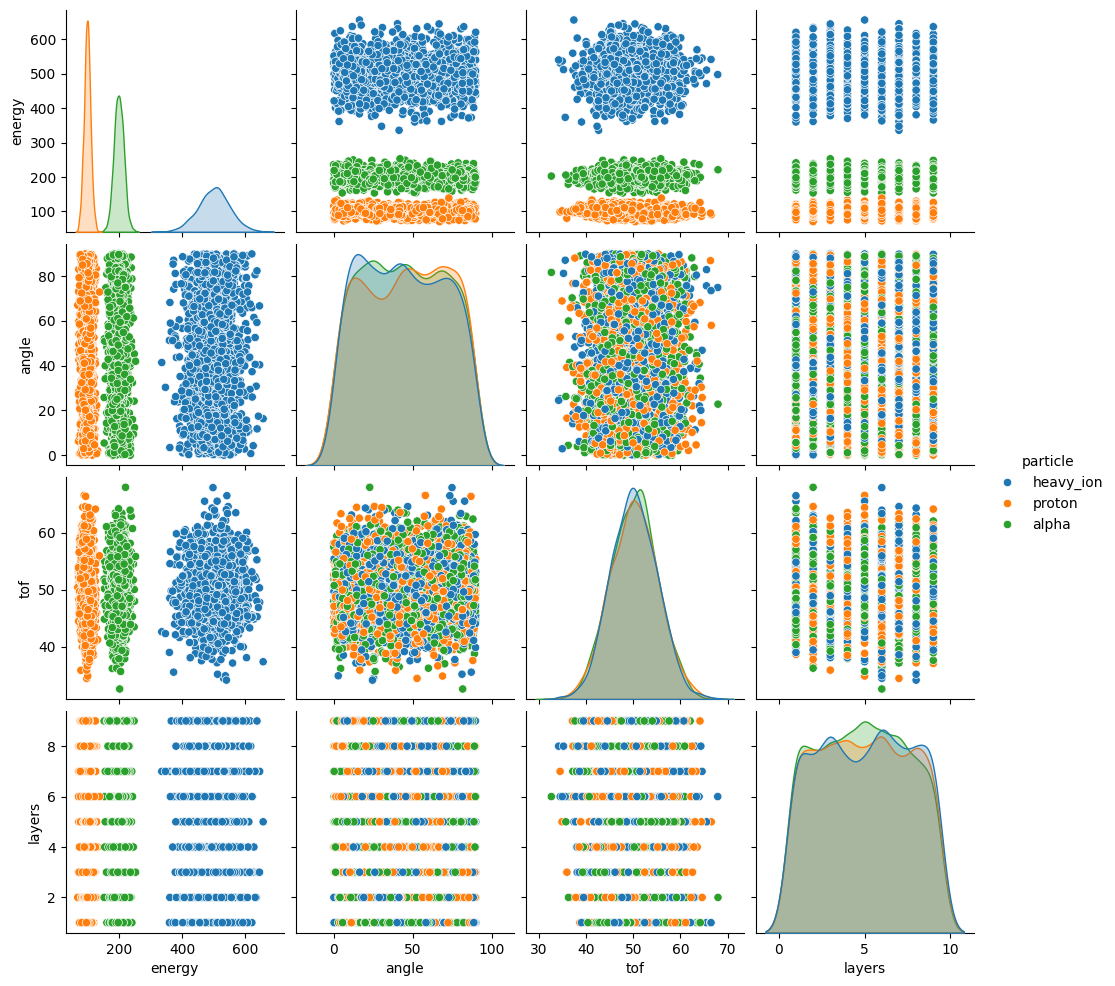

Logistic Regression:
              precision    recall  f1-score   support

       alpha       1.00      1.00      1.00       361
   heavy_ion       1.00      1.00      1.00       304
      proton       1.00      1.00      1.00       335

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Random Forest:
              precision    recall  f1-score   support

       alpha       1.00      1.00      1.00       361
   heavy_ion       1.00      1.00      1.00       304
      proton       1.00      1.00      1.00       335

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



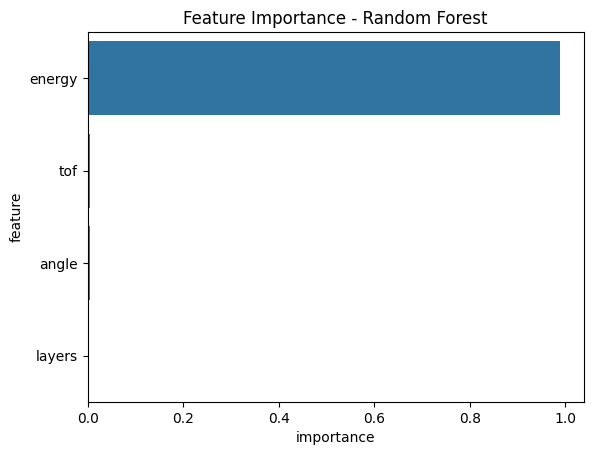

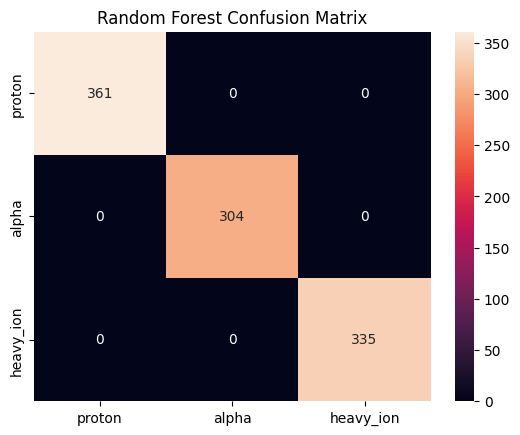

Epoch 1: Loss=0.9490900635719299
Epoch 2: Loss=0.7360627055168152
Epoch 3: Loss=0.617133378982544
Epoch 4: Loss=0.5847519636154175
Epoch 5: Loss=0.5643704533576965
Epoch 6: Loss=0.5570013523101807
Epoch 7: Loss=0.5572874546051025
Epoch 8: Loss=0.5537229776382446
Epoch 9: Loss=0.5540192127227783
Epoch 10: Loss=0.5531991720199585
Epoch 11: Loss=0.5537031292915344
Epoch 12: Loss=0.5523445010185242
Epoch 13: Loss=0.5527522563934326
Epoch 14: Loss=0.5520889163017273
Epoch 15: Loss=0.5522472858428955
Epoch 16: Loss=0.5528374314308167
Epoch 17: Loss=0.5516690611839294
Epoch 18: Loss=0.5516537427902222
Epoch 19: Loss=0.551594614982605
Epoch 20: Loss=0.5515649914741516
Epoch 21: Loss=0.5520942211151123
Epoch 22: Loss=0.5518515706062317
Epoch 23: Loss=0.5535494089126587
Epoch 24: Loss=0.5517327785491943
Epoch 25: Loss=0.5519866943359375
Epoch 26: Loss=0.5517590045928955
Epoch 27: Loss=0.5515336990356445
Epoch 28: Loss=0.551567018032074
Epoch 29: Loss=0.5515034794807434
Epoch 30: Loss=0.551483869

d:\cosmic-ray-classifer\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [4]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import plotly.express as px
import random


# Synthetic Dataset Generation

# Particle types
particle_types = ['proton', 'alpha', 'heavy_ion']

# Function to simulate a single cosmic ray event
def simulate_event():
    particle = random.choice(particle_types)
    
    # Energy deposit in MeV (example ranges)
    if particle == 'proton':
        energy = np.random.normal(100, 10)
    elif particle == 'alpha':
        energy = np.random.normal(200, 15)
    else:  # heavy ion
        energy = np.random.normal(500, 50)
    
    # Incidence angle in degrees (0 = straight down)
    angle = np.random.uniform(0, 90)
    
    # Time-of-flight in nanoseconds
    tof = np.random.normal(50, 5)
    
    # Detector layer hits (integer number of layers)
    layers = np.random.randint(1, 10)
    
    # Add some random noise
    energy += np.random.normal(0, 2)
    tof += np.random.normal(0, 1)
    
    return [energy, angle, tof, layers, particle]

# Generate dataset

num_events = 5000
data = [simulate_event() for _ in range(num_events)]
df = pd.DataFrame(data, columns=['energy', 'angle', 'tof', 'layers', 'particle'])


# Exploratory Data Analysis

print(df.head())
print(df['particle'].value_counts())

# Pairplot
sns.pairplot(df, hue='particle')
plt.show()

# 3D Scatter plot with Plotly
fig = px.scatter_3d(df, x='energy', y='angle', z='tof', color='particle')
fig.show(renderer="browser")

# Preprocessing & Feature Engineering
X = df[['energy', 'angle', 'tof', 'layers']]
y = df['particle']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Model Training & Evaluation


# Logistic Regression
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Feature importance
feat_importance = pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
feat_importance = feat_importance.sort_values(by='importance', ascending=False)
sns.barplot(data=feat_importance, x='importance', y='feature')
plt.title("Feature Importance - Random Forest")
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=particle_types, yticklabels=particle_types)
plt.title("Random Forest Confusion Matrix")
plt.show()


# Neural Network (PyTorch or TensorFlow)

# Example with PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(pd.get_dummies(y_train).values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(pd.get_dummies(y_test).values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 3)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))
        return x

model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop (simplified)
for epoch in range(50):
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, torch.argmax(yb, axis=1))
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss={loss.item()}")


In [5]:
try:
    model = joblib.load("rf_model.pkl")
    scaler = joblib.load("scaler.pkl")
except:
    model, scaler = create_model()

In [9]:

import gradio as gr
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# Train a simple model (if not already trained)

# This section ensures the demo runs even if you don't load pre-trained files.
# In production, you can save the trained model (rf_model.pkl) and scaler (scaler.pkl)
# and just load them using joblib.load().

def create_model():
    # Simulate training data (same logic from the notebook)
    particle_types = ['proton', 'alpha', 'heavy_ion']

    def simulate_event():
        particle = np.random.choice(particle_types)
        if particle == 'proton':
            energy = np.random.normal(100, 10)
        elif particle == 'alpha':
            energy = np.random.normal(200, 15)
        else:
            energy = np.random.normal(500, 50)
        angle = np.random.uniform(0, 90)
        tof = np.random.normal(50, 5)
        layers = np.random.randint(1, 10)
        energy += np.random.normal(0, 2)
        tof += np.random.normal(0, 1)
        return [energy, angle, tof, layers, particle]

    data = [simulate_event() for _ in range(2000)]
    df = pd.DataFrame(data, columns=['energy', 'angle', 'tof', 'layers', 'particle'])

    X = df[['energy', 'angle', 'tof', 'layers']]
    y = df['particle']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_scaled, y)

    # Save model and scaler
    joblib.dump(model, "rf_model.pkl")
    joblib.dump(scaler, "scaler.pkl")
    return model, scaler

try:
    model = joblib.load("rf_model.pkl")
    scaler = joblib.load("scaler.pkl")
except:
    model, scaler = create_model()


# Define prediction function

def predict_particle(energy, angle, tof, layers):
    input_data = pd.DataFrame([[energy, angle, tof, layers]], columns=['energy', 'angle', 'tof', 'layers'])
    input_scaled = scaler.transform(input_data)
    pred = model.predict(input_scaled)[0]

    # Predict probabilities
    probs = model.predict_proba(input_scaled)[0]
    confidence = round(max(probs) * 100, 2)
    return {
        "Predicted Particle": pred,
        "Confidence (%)": confidence,
        "Class Probabilities": {
            str(cls): f"{round(float(p)*100,2)}%" for cls, p in zip(model.classes_, probs)
        }

    }


# Build Gradio Interface

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # ☄️ Cosmic Ray Particle Classifier  
    Simulate cosmic ray detector readings and classify particle type using AI.  
    """)

    with gr.Row():
        energy = gr.Slider(0, 1000, 100, label="Energy Deposit (MeV)")
        angle = gr.Slider(0, 90, 30, label="Incidence Angle (°)")
    with gr.Row():
        tof = gr.Slider(0, 100, 50, label="Time-of-Flight (ns)")
        layers = gr.Slider(1, 10, 5, step=1, label="Detector Layer Hits")

    predict_btn = gr.Button("🚀 Classify Particle")

    output = gr.JSON(label="Prediction Result")

    predict_btn.click(
        fn=predict_particle,
        inputs=[energy, angle, tof, layers],
        outputs=output
    )


# Launch App

if __name__ == "__main__":
    demo.launch()


* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
